**Handwritten Digit Recognition**

Setup: installs kagglehub and creates the project folder

In [1]:
!pip install kagglehub -q
!mkdir -p mnist-digit-recognition
%cd mnist-digit-recognition

/content/mnist-digit-recognition


Kaggle auth: logs in so kagglehub can download the dataset

In [2]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


1. **requirements.txt**: writes the list of required packages

In [3]:
%%writefile requirements.txt
torch>=2.0.0
numpy>=1.24.0
pandas>=2.0.0
matplotlib>=3.7.0
kagglehub>=0.2.0

Writing requirements.txt


2. **data_prep.py**: writes the script that downloads and preprocesses MNIST

In [4]:
%%writefile data_prep.py
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

def get_data_dir():
    import kagglehub
    return Path(kagglehub.dataset_download("oddrationale/mnist-in-csv"))

def load_csv(path):
    df = pd.read_csv(path)
    values = df.values.astype(np.float32)
    return values[:, 1:], values[:, 0].astype(np.int64)

def prepare_data():
    data_dir = get_data_dir()
    X_train, y_train = load_csv(data_dir / "mnist_train.csv")
    X_test, y_test = load_csv(data_dir / "mnist_test.csv")
    X_train, X_test = X_train / 255.0, X_test / 255.0

    print(f"Train images: {X_train.shape[0]}, Test images: {X_test.shape[0]}")
    print(f"Image dim: {X_train.shape[1]} (28x28 flattened), Classes: {sorted(np.unique(y_train).tolist())}")

    fig, axes = plt.subplots(2, 5, figsize=(10, 5.5))
    for digit in range(10):
        idx = np.where(y_train == digit)[0][0]
        ax = axes[digit // 5, digit % 5]
        ax.imshow(X_train[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Label: {digit}")
        ax.axis("off")
    plt.suptitle("One sample image per digit class (0-9)")
    plt.subplots_adjust(hspace=0.5, top=0.88)
    plt.savefig(OUTPUT_DIR / "sample_digits.png", dpi=150)
    plt.close()

    return X_train, y_train, X_test, y_test

if __name__ == "__main__":
    prepare_data()

Writing data_prep.py


3. **train.py**: writes the script that builds, trains, and evaluates the model

In [5]:
%%writefile train.py
import argparse, json
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from data_prep import prepare_data

OUTPUT_DIR = Path("outputs")
torch.manual_seed(42)

class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim=784, num_classes=10):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)
    def forward(self, x):
        return self.linear(x)

def main():
    p = argparse.ArgumentParser()
    p.add_argument("--epochs", type=int, default=20)
    p.add_argument("--batch-size", type=int, default=64)
    p.add_argument("--lr", type=float, default=0.01)
    args = p.parse_args()

    X_train, y_train, X_test, y_test = prepare_data()
    train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train)), batch_size=args.batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test)), batch_size=args.batch_size)

    model = LogisticRegressionModel()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=args.lr)

    losses = []
    for epoch in range(1, args.epochs + 1):
        total, n = 0.0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            total += loss.item(); n += 1
        losses.append(total / n)
        print(f"Epoch {epoch:2d}/{args.epochs} - avg training loss: {losses[-1]:.4f}")

    model.eval()
    correct, total_n = 0, 0
    confusion = np.zeros((10, 10), dtype=np.int64)
    with torch.no_grad():
        for xb, yb in test_loader:
            preds = torch.argmax(model(xb), dim=1)
            correct += (preds == yb).sum().item(); total_n += yb.size(0)
            for t, pr in zip(yb.numpy(), preds.numpy()):
                confusion[t, pr] += 1
    accuracy = correct / total_n
    print(f"\nTest accuracy: {accuracy*100:.2f}%")

    plt.figure(figsize=(6,4))
    plt.plot(range(1, args.epochs+1), losses, marker="o")
    plt.xlabel("Epoch"); plt.ylabel("Average training loss")
    plt.title("Training Loss over Epochs"); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / "training_loss.png", dpi=150); plt.close()

    plt.figure(figsize=(6,5))
    plt.imshow(confusion, cmap="Blues"); plt.colorbar()
    plt.xticks(range(10)); plt.yticks(range(10))
    plt.xlabel("Predicted label"); plt.ylabel("True label")
    plt.title("Confusion Matrix (Test Set)")
    for i in range(10):
        for j in range(10):
            c = "white" if confusion[i,j] > confusion.max()/2 else "black"
            plt.text(j, i, str(confusion[i,j]), ha="center", va="center", color=c, fontsize=7)
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150); plt.close()

    torch.save(model.state_dict(), OUTPUT_DIR / "model.pt")
    metrics = {
        "epochs": args.epochs, "batch_size": args.batch_size, "learning_rate": args.lr,
        "final_train_loss": losses[-1], "test_accuracy": accuracy,
        "per_class_accuracy": {str(i): float(confusion[i,i]/confusion[i].sum()) for i in range(10)},
        "epoch_losses": losses,
    }
    with open(OUTPUT_DIR / "metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)
    print("Saved model, metrics, and figures to outputs/")

if __name__ == "__main__":
    main()

Writing train.py


Run training: runs train.py to train the model and save results

In [6]:
!python train.py --epochs 20 --batch-size 64 --lr 0.01

Using Colab cache for faster access to the 'mnist-in-csv' dataset.
Train images: 60000, Test images: 10000
Image dim: 784 (28x28 flattened), Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Epoch  1/20 - avg training loss: 0.9763
Epoch  2/20 - avg training loss: 0.5516
Epoch  3/20 - avg training loss: 0.4722
Epoch  4/20 - avg training loss: 0.4333
Epoch  5/20 - avg training loss: 0.4091
Epoch  6/20 - avg training loss: 0.3925
Epoch  7/20 - avg training loss: 0.3797
Epoch  8/20 - avg training loss: 0.3698
Epoch  9/20 - avg training loss: 0.3618
Epoch 10/20 - avg training loss: 0.3550
Epoch 11/20 - avg training loss: 0.3491
Epoch 12/20 - avg training loss: 0.3441
Epoch 13/20 - avg training loss: 0.3397
Epoch 14/20 - avg training loss: 0.3357
Epoch 15/20 - avg training loss: 0.3323
Epoch 16/20 - avg training loss: 0.3291
Epoch 17/20 - avg training loss: 0.3263
Epoch 18/20 - avg training loss: 0.3236
Epoch 19/20 - avg training loss: 0.3211
Epoch 20/20 - avg training loss: 0.3188

Test accuracy: 91.

View results: displays the sample digits, loss curve, and confusion matrix

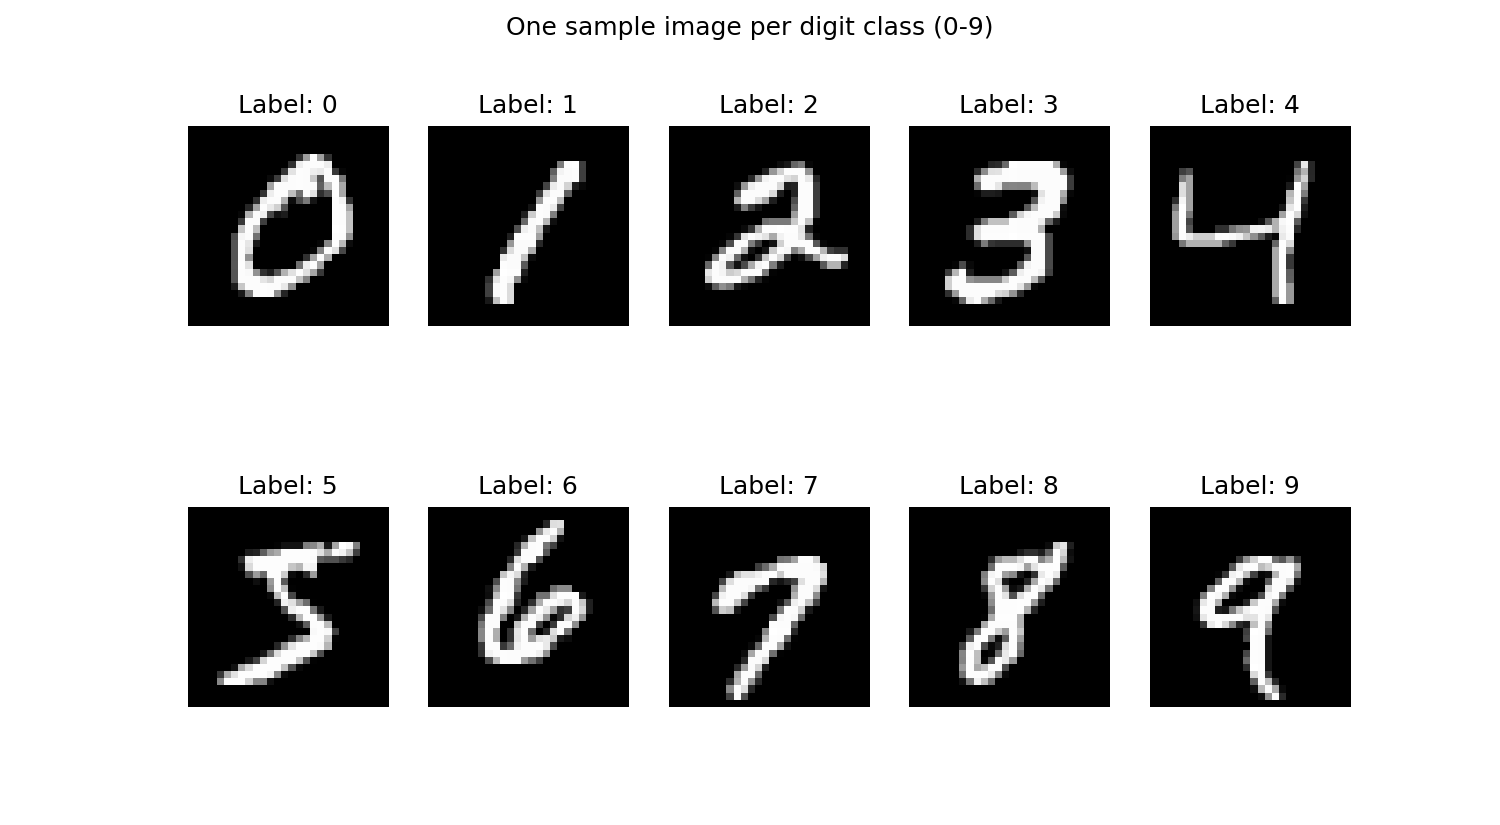

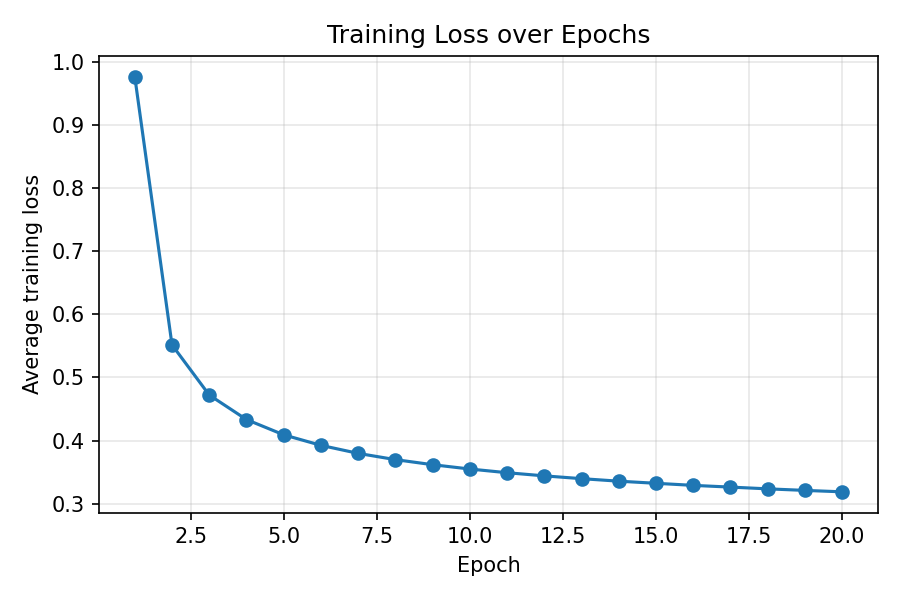

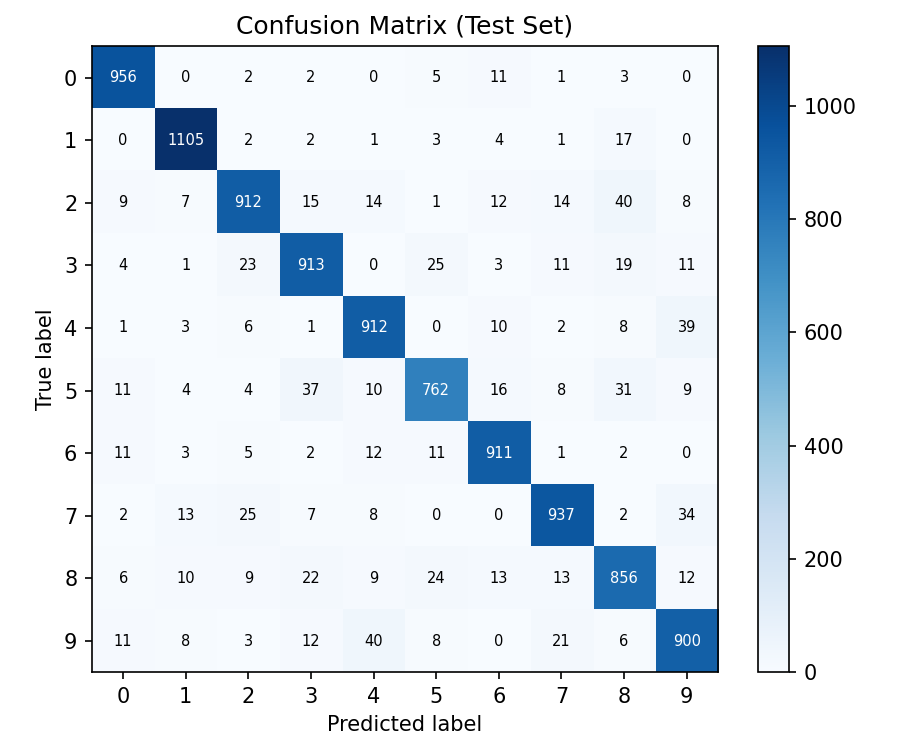

In [9]:
from IPython.display import Image, display
display(Image('outputs/sample_digits.png'))
display(Image('outputs/training_loss.png'))
display(Image('outputs/confusion_matrix.png'))

4. **predict.py**: writes the script that loads the saved model and predicts without retraining

In [10]:
%%writefile predict.py
import argparse
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
from data_prep import prepare_data
from train import LogisticRegressionModel

OUTPUT_DIR = Path("outputs")

def main():
    p = argparse.ArgumentParser()
    p.add_argument("--index", type=int, default=None)
    args = p.parse_args()

    _, _, X_test, y_test = prepare_data()
    model = LogisticRegressionModel()
    model.load_state_dict(torch.load(OUTPUT_DIR / "model.pt", map_location="cpu"))
    model.eval()

    if args.index is not None:
        x = torch.tensor(X_test[args.index], dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            probs = torch.softmax(model(x), dim=1).squeeze().numpy()
        pred = int(np.argmax(probs))
        true_label = int(y_test[args.index])
        print(f"Test image #{args.index}: true label = {true_label}, predicted = {pred}")
        plt.imshow(X_test[args.index].reshape(28, 28), cmap="gray")
        plt.title(f"True: {true_label} | Predicted: {pred}")
        plt.axis("off")
        plt.savefig(OUTPUT_DIR / f"prediction_{args.index}.png", dpi=150)
        print(f"Saved visualization to outputs/prediction_{args.index}.png")
    else:
        X_t = torch.tensor(X_test, dtype=torch.float32)
        with torch.no_grad():
            preds = torch.argmax(model(X_t), dim=1).numpy()
        accuracy = (preds == y_test).mean()
        print(f"Accuracy on full test set: {accuracy*100:.2f}%")

if __name__ == "__main__":
    main()

Overwriting predict.py


Run prediction: tests the saved model without retraining

In [11]:
!python predict.py
!python predict.py --index 17

Using Colab cache for faster access to the 'mnist-in-csv' dataset.
Train images: 60000, Test images: 10000
Image dim: 784 (28x28 flattened), Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Accuracy on full test set: 91.64%
Using Colab cache for faster access to the 'mnist-in-csv' dataset.
Train images: 60000, Test images: 10000
Image dim: 784 (28x28 flattened), Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Test image #17: true label = 7, predicted = 7
Saved visualization to outputs/prediction_17.png


View visualization output

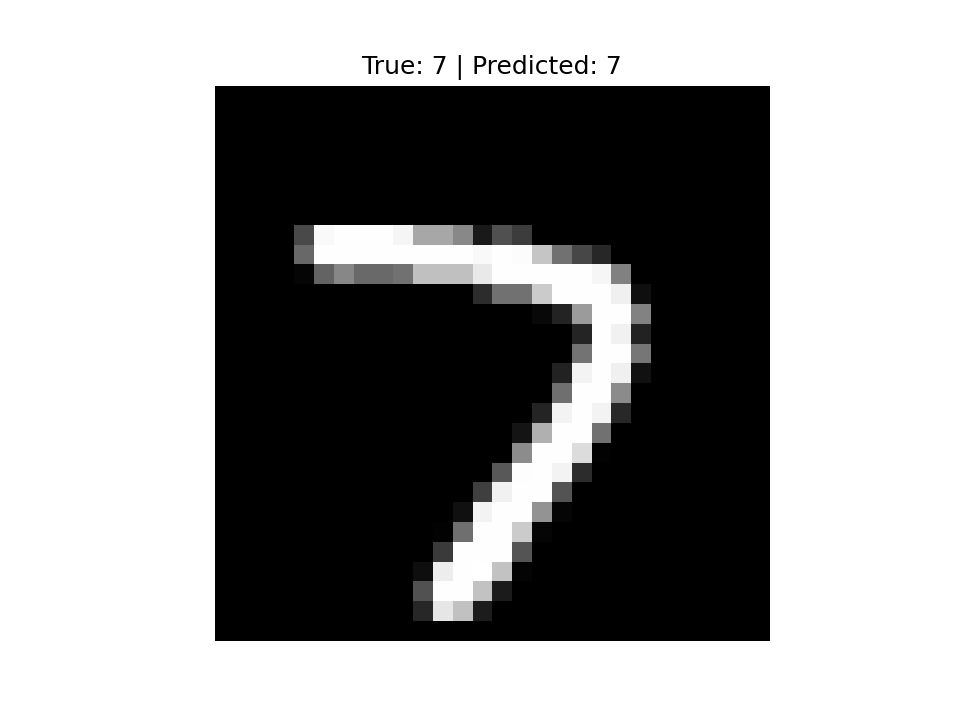

In [13]:
Image('outputs/prediction_17.png')